Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.5478 - val_loss: 0.2823
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2650 - val_loss: 0.2307
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2286 - val_loss: 0.2148
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.2133 - val_loss: 0.2032
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.2024 - val_loss: 0.1941
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1941 - val_loss: 0.1877
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1882 - val_loss: 0.1829
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1841 - val_loss: 0.1792
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1804 - val_loss: 0.1763
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1775 - val_loss: 0.1738
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1758 - val_loss: 0.1715
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/ste

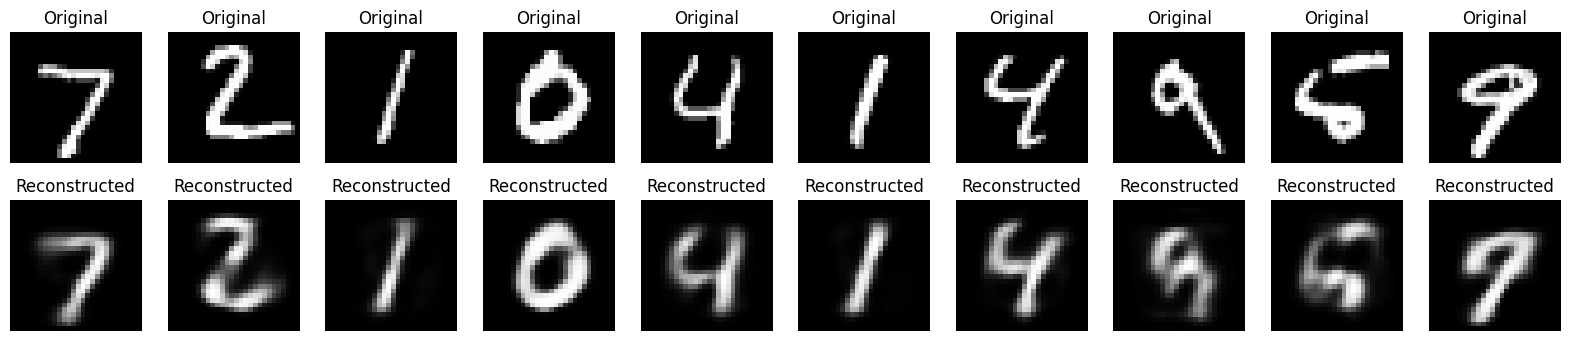

In [39]:
# ====================================================
# Sparse Autoencoder for MNIST Reconstruction
# ====================================================
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

# --- Step 1: Load and preprocess data ---
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images (28x28 -> 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# --- Step 2: Build Sparse Autoencoder ---
encoding_dim = 64  # number of neurons in bottleneck 

input_img = tf.keras.Input(shape=(784,))

# Encoder with L1 sparsity regularization
encoded = layers.Dense(
    encoding_dim, 
    activation='relu', 
    activity_regularizer=regularizers.l1(1e-5)  # sparsity constraint
)(input_img)

# Decoder
decoded = layers.Dense(784, activation='sigmoid')(encoded)

# Full autoencoder model
autoencoder = models.Model(input_img, decoded)

# --- Step 3: Compile ---
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# --- Step 4: Train ---
autoencoder.fit(
    x_train, x_train,
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

# --- Step 5: Encode and decode some test images ---
encoded_imgs = autoencoder.layers[1](x_test).numpy()
decoded_imgs = autoencoder.predict(x_test)

# --- Step 6: Display original vs reconstructed images ---
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()
